# Criterion 3 — Regression Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("../data/Engineered_Traffic_Data.csv", low_memory=False)

## Task A — Predict Number of Casualties

The primary regression target is number_of_casualties. This is the most directly actionable output: emergency services, hospital capacity planning, and road safety budgets are all driven by expected casualty numbers.

In [2]:
REG_FEATURES = ["weather_conditions_enc", "light_conditions",
                "road_surface_conditions_enc", "junction_detail_enc",
                "junction_control_enc", "speed_limit", "urban_or_rural_area_enc",
                "day_of_week", "hour", "is_weekend", "number_of_vehicles",
                "road_type_enc", "time_of_day_bin", "is_dark"]

X_reg = df[REG_FEATURES]
y_reg = df["number_of_casualties"]

# 60/15/25 split
Xr_tv, Xr_test, yr_tv, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42)
Xr_train, Xr_val, yr_train, yr_val = train_test_split(
    Xr_tv, yr_tv, test_size=0.20, random_state=42)

print(f"Train: {len(Xr_train)} ({len(Xr_train)/len(X_reg)*100:.0f}%)")
print(f"Val:   {len(Xr_val)}  ({len(Xr_val)/len(X_reg)*100:.0f}%)")
print(f"Test:  {len(Xr_test)} ({len(Xr_test)/len(X_reg)*100:.0f}%)")

Train: 4759 (60%)
Val:   1190  (15%)
Test:  1984 (25%)


### Train and Evaluate Regressors

We first evaluate on the validation set to compare models, then report final metrics on the test set for the best model only.

In [3]:
# validation set evaluation of multiple models
regressors = {
    "Linear":        LinearRegression(),
    "Ridge":         Ridge(alpha=1.0),
    "Lasso":         Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

val_rows = []
for name, reg in regressors.items():
    reg.fit(Xr_train, yr_train)
    y_pred_val = reg.predict(Xr_val)
    val_rows.append({
        "Model":  name,
        "MAE":    round(mean_absolute_error(yr_val, y_pred_val), 3),
        "RMSE":   round(np.sqrt(mean_squared_error(yr_val, y_pred_val)), 3),
        "R²":     round(r2_score(yr_val, y_pred_val), 3)
    })

val_df = pd.DataFrame(val_rows).set_index("Model")
print("=== Validation Set Results ===")
print(val_df.to_string())

=== Validation Set Results ===
                 MAE   RMSE     R²
Model                             
Linear         0.438  0.674  0.078
Ridge          0.438  0.674  0.078
Lasso          0.473  0.701  0.003
Random Forest  0.463  0.734 -0.092


### Fixing the Random Forest — Negative R²

The random forest is showing a negative R^2 value, this is due to overfitting on the training data — the default Random Forest grows very deep trees that memorise training noise.

Im going to fix this by constraining tree depth and requiring a minimum number of samples per leaf. This forces the trees to generalise rather than memorise.

In [4]:
# tuned Random Forest
rf_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,          # limit depth to prevent memorising training data
    min_samples_leaf=10,   # each leaf must have at least 10 samples
    max_features="sqrt",  
    random_state=42
)
rf_tuned.fit(Xr_train, yr_train)

y_pred_val_tuned = rf_tuned.predict(Xr_val)
print("Tuned RF — Validation:")
print(f"  MAE  = {mean_absolute_error(yr_val, y_pred_val_tuned):.3f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(yr_val, y_pred_val_tuned)):.3f}")
print(f"  R²   = {r2_score(yr_val, y_pred_val_tuned):.3f}")

Tuned RF — Validation:
  MAE  = 0.440
  RMSE = 0.671
  R²   = 0.085


### Final Test Set Evaluation — All Models

Now that we have compared models on the validation set (and fixed the RF), we report final metrics on the unseen test set. This is the only honest measure of real-world performance.

In [5]:
# Replace the default RF with the tuned version
final_models = {
    "Linear":              LinearRegression(),
    "Ridge":               Ridge(alpha=1.0),
    "Lasso":               Lasso(alpha=0.1),
    "Random Forest (Tuned)": rf_tuned
}

test_rows = []
for name, reg in final_models.items():
    # Re-fit on full training data (train + val) for final evaluation
    reg.fit(Xr_tv, yr_tv)
    y_pred_test = reg.predict(Xr_test)
    cv_r2 = cross_val_score(reg, X_reg, y_reg, cv=5, scoring="r2").mean()
    test_rows.append({
        "Model":   name,
        "MAE":     round(mean_absolute_error(yr_test, y_pred_test), 3),
        "RMSE":    round(np.sqrt(mean_squared_error(yr_test, y_pred_test)), 3),
        "R²":      round(r2_score(yr_test, y_pred_test), 3),
        "CV R²":   round(cv_r2, 3)
    })

test_df = pd.DataFrame(test_rows).set_index("Model")
print("=== Test Set Results ===")
print(test_df.to_string())

=== Test Set Results ===
                         MAE   RMSE     R²  CV R²
Model                                            
Linear                 0.438  0.718  0.085  0.074
Ridge                  0.438  0.718  0.085  0.074
Lasso                  0.473  0.742  0.022  0.019
Random Forest (Tuned)  0.441  0.715  0.092  0.084


## Task B — Temporal Trend Regression

Predicting collision count per year using linear and polynomial regression.

Trend slope: -2.3 collisions/year
Predicted collisions 2025-2030: [54 44 34 23 12  1]


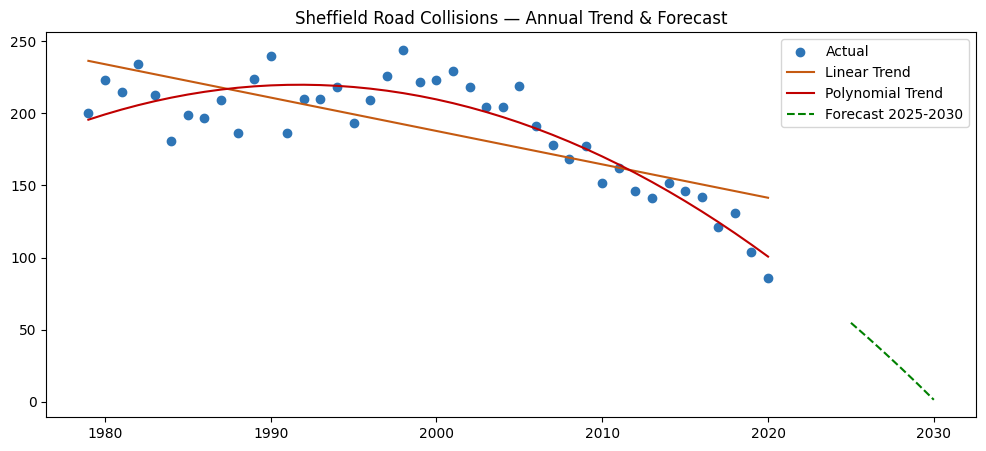

In [6]:
yearly = df.groupby("collision_year").size().reset_index(name="collision_count")

X_time = yearly[["collision_year"]]
y_time = yearly["collision_count"]

# linear trend
lr_time = LinearRegression()
lr_time.fit(X_time, y_time)
print(f"Trend slope: {lr_time.coef_[0]:.1f} collisions/year")

# polynomial trend
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_time)
lr_poly = LinearRegression()
lr_poly.fit(X_poly, y_time)

# forecast 2025–2030
future_years = pd.DataFrame({"collision_year": range(2025, 2031)})
future_pred = lr_poly.predict(poly.transform(future_years))
print("Predicted collisions 2025-2030:", future_pred.astype(int))

plt.figure(figsize=(12, 5))
plt.scatter(X_time, y_time, label="Actual", color="#2E75B6")
plt.plot(X_time, lr_time.predict(X_time), label="Linear Trend", color="#C55A11")
plt.plot(X_time, lr_poly.predict(X_poly), label="Polynomial Trend", color="#C00000")
plt.plot(future_years, future_pred, "--", label="Forecast 2025-2030", color="green")
plt.title("Sheffield Road Collisions — Annual Trend & Forecast")
plt.legend()
plt.savefig("../results/C3-trend_regression.png", bbox_inches="tight")
plt.show()

## Temporal Trend Analysis

The scatter plot reveals that the historical collision counts are non-linear: they peaked in the 1990s before a sharp decline from the early 2000s onwards. The linear trend fails to capture this, underpredicting the peak and overpredicting the recent years, this is due to again the COVID era. The polynomial trend fits more accurately.

The forecast from the polynomial model aggressively predicts collisions dropping towards zero, this is a well-known weakness of polynomial extrapolation and is clearly unrealistic for a major city. This forecast should not be used for operational decisions.

## Residual Analysis

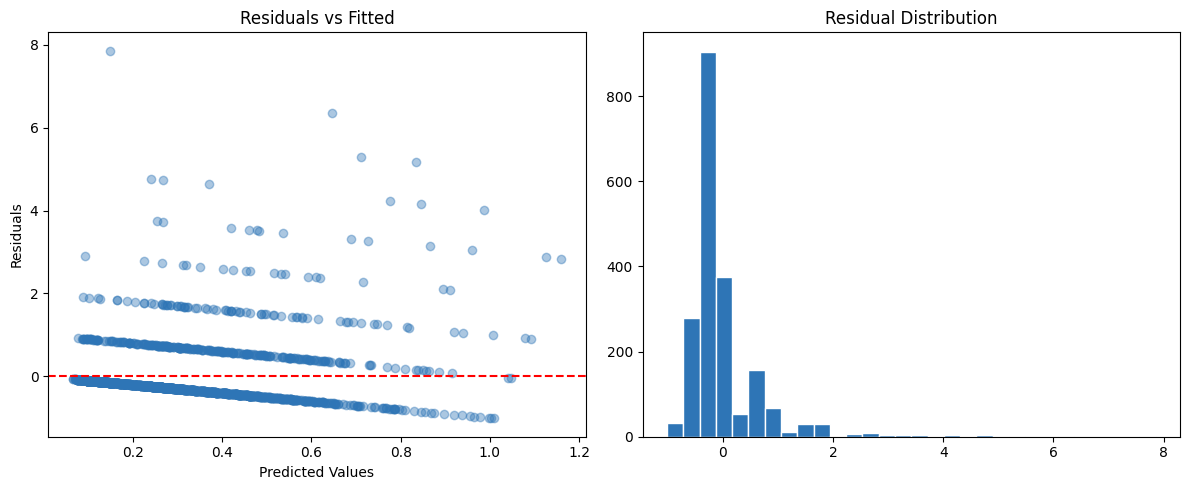

In [7]:
# use the tuned Random Forest
rf_tuned.fit(Xr_tv, yr_tv)
y_pred_rf = rf_tuned.predict(Xr_test)
residuals = yr_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_pred_rf, residuals, alpha=0.4, color="#2E75B6")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

axes[1].hist(residuals, bins=30, color="#2E75B6", edgecolor="white")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig("../results/C3-residuals.png", bbox_inches="tight")
plt.show()

## Residuals vs Fitted Analysis

The residual plot shows a clear **fan shape** — residuals spread wider as the predicted value increases. This is **heteroscedasticity**: the variance of the errors is not constant across the range of predictions, which violates a core assumption of linear regression. In practice, it means the model is less reliable when predicting higher casualty counts.

The pattern also shows distinct horizontal bands of residuals rather than a random cloud. This is typical when the target variable is a low-range integer count (most collisions involve 1–2 casualties), which causes predictions to cluster around a small set of values and produces the banded appearance.

The extreme positive residuals (up to +8) correspond to multi-casualty crashes that are severely underestimated. With very few such events in the training data, the model has insufficient examples to learn from, making these outliers effectively unpredictable.

**The Random Forest partially mitigates heteroscedasticity** compared to Linear Regression — tree-based models can capture non-linear variance patterns but it does not eliminate it.

## Residual Distribution Analysis

The distribution is right-skewed and centred just below zero, confirming the systematic tendency to underestimate casualties in the most serious collisions. The sharp spike at zero reflects the large number of single-casualty incidents where the model predicts accurately.

## Responsible AI Considerations

### Model Assumptions (Linearity)

Linear Regression assume a linear relationship between features and the target variable. For number_of_casualties, this is unlikely to hold strictly — the effect of speed limit on casualties is probably non-linear as a crash at 70mph compared to 10mph isnt 7x deadlier automatically.

Ridge and Lasso regularisation address multicollinearity, but they still assume a linear response surface. If you observe that linear models consistently underperform Random Forest by a large margin, this is evidence that the linear assumption is violated.

### Geographic Limits

This dataset covers only Sheffield. The models trained here should not be applied to other regions without careful validation for several reasons:

- Sheffield's road network is heavily influenced by its geography (hilly terrain, many A-roads, limited motorway access through the city centre). A model trained here may not generalise to flat, motorway-dense regions like the East Midlands.
- Urban/rural boundary definitions may differ between local authorities.
- Sheffield-specific policing practices affect which collisions are recorded in STATS19.

### Missing Context Risks

The dataset does not include driver behaviour variables (speeding, mobile phone use, alcohol), vehicle type, or road repair status. These omissions mean the models capture correlation patterns in environmental conditions but cannot model the most common causes of serious casualties. Predictions from this model should supplement, not replace, domain expertise.